In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import xarray as xr
import itertools
import scipy as sp
import warnings

import sys
import pathlib
sys.path.append(str(pathlib.Path.cwd().parent.parent))
import ISRUtilities as isru
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [6]:
def _laggedSpikeCrossCorr(session,regs=None,window=0.1,shift=-1,pairs=None):
    # compute lagged cross-region pairwise unit correlation around event times as (shuffle, region, lag) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = fma.regions.regions(session,events=['InfraSlowRhythm/infraslowaval'])
    regs = R.ids if regs is None else np.array(regs)
    reg_pair_idx = list(itertools.permutations(range(len(regs)),2)) if pairs is None else pairs
    reg_pairs = [f'{regs[rp[0]]}-{regs[rp[1]]}' for rp in reg_pair_idx]
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids
    unit_range = {regs[i]: [R.spikes(regs[i])[:,1].min(),R.spikes(regs[i])[:,1].max()] if r else None for i, r in enumerate(is_reg)}

    events = isru.loadHpcPfcEvents(session)
    event_t = events['deltaWaves']

    # 1. count spikes in overlapping windows around event times
    n_strides = 7 # time resolution will be win_size / n_strides
    n_bins = 12
    limits = (-n_bins*window/2, n_bins*window/2)
    n_times = (n_bins-1) * n_strides + 1
    peths = {}
    for j, r in enumerate(regs[is_reg]):
        s = R.spikes(r)
        peths[r], times, _ = fma.analysis.PETH(s[:,0],event_t,limits=limits,n_bins=n_bins,step=n_strides,groups=s[:,1],g_range=unit_range[r],fast=True) # (n_ripples, n_lags, n_units)

    spearman = np.full((2,len(reg_pairs),n_times),np.nan)
    for i, rp in enumerate(reg_pair_idx):
        if is_reg[rp[0]] and is_reg[rp[1]]:
            ref_peth = peths[regs[rp[0]]]
            for k in [0,1]:
                    # surrogate: roll across events
                    lagged_peth = np.roll(peths[regs[rp[1]]],shift=shift,axis=0) if k else peths[regs[rp[1]]]
                    n_keep_units = lagged_peth.shape[2] # used to recover the cross-correlation block in spearmanr output

                    #with warnings.catch_warnings():
                        #warnings.filterwarnings('ignore', category=sp.stats.ConstantInputWarning)
                    for t in range(len(times)):
                        with np.errstate(invalid='ignore'): # suppress 0 / 0 warning
                            spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
                        spearman[k,i,t] = np.nanmean(np.abs(spr[:n_keep_units,n_keep_units:]))

    spearman = xr.DataArray(spearman,dims=('shuffle','region','lag'),coords={'shuffle': [False,True],'region': reg_pairs,'lag': times,'rat': int(R.rat)})

    return spearman

IndentationError: unindent does not match any outer indentation level (<string>, line 39)

In [3]:
# test one session
session = fma.data.readBatchFile(batch_file)[0][30]
print(f'session: {session}')
xdata = _laggedSpikeCrossCorr(session,shift=5,window=0.05)

session: /mnt/hubel-data-140/karadoc/Rat004_20240319/Rat004_20240319.xml


/tmp/ipykernel_3856262/2137174787.py:43: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]


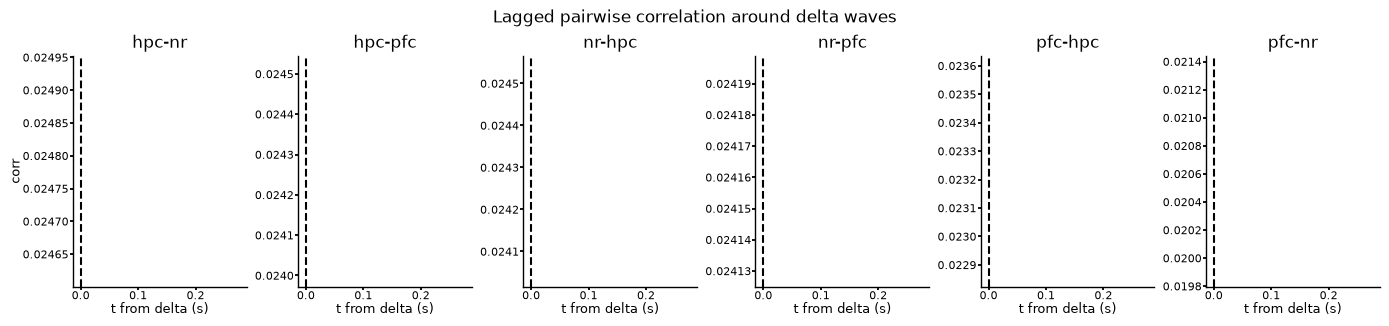

In [5]:
# interpretation: reg1 pop vector at transition correlated with reg2's delayed
fig, axs = fma.plotting.makeFigure('Lagged pairwise correlation around delta waves',[1,6],[35,8])
for i, r in enumerate(xdata['region']):
    reg_data = xdata.sel(region=r)
    fma.plotting.semPlot(xdata['lag'],reg_data.sel(shuffle=True),zscore=False,color=isru.paperColors('shuffle'),label=str(r.item().upper()),ax=axs[i])
    axs[i].plot(xdata['lag'],reg_data.sel(shuffle=False),color=isru.paperColors(i),label=str(r.item().upper()))
    axs[i].set_xlabel('t from delta (s)'), axs[i].set_title(r.values)
    axs[i].axvline(0,ls='--',color='k')
axs[0].set_ylabel('corr');

run batch

In [7]:
regs = ['hpc','nr','pfc']
corr = fma.data.runBatch(batch_file,_laggedSpikeCrossCorr,kwargs={'regs': regs, 'shift': -5},parallel=True)


Starting Batch, 2026-07-29 12:05:05.494969 



/tmp/ipykernel_3841402/2082265120.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
/tmp/ipykernel_3841402/2082265120.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
/tmp/ipykernel_3841402/2082265120.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
/tmp/ipykernel_3841402/2082265120.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearmanr(lagged_peth[:,t,:],ref_peth[:,n_times//2,:])[0]
/tmp/ipykernel_3841402/2082265120.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spr = sp.stats.spearman

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
need at least one array to concatenate
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
need at least one array to concatenate
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
need at least one array to concatenate
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
need at least one array to concatenate
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
need at least one array to concatenate
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230817/Rat002_20230817.xml (36)
need at least one array to concatenate
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230818/Rat002_20230818.xml (37)
need at least one array to concatenate
Tra